# Stage 0. Data Harmonization and EDA

Notebook ini menyatukan dataset CP-AnemiC dan Eyes-Defy menjadi satu manifest terunifikasi, menurunkan label biner anemia memakai ambang sesuai populasi, lalu menampilkan eksplorasi distribusi hemoglobin, severity, dan situs.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import pandas as pd
import matplotlib.pyplot as plt

from configs import paths
from src.common import manifest as manifest_utils
from src.sites.conjunctiva import data

print(paths.dataset_root("conjunctiva"))

/home/praktikan/projects/Azril/hemavision/dataset/conjunctiva


## Build Unified Manifest

Membangun manifest terunifikasi dari kedua dataset. Setiap baris mewakili satu pasien dengan path citra region of interest, kadar hemoglobin, demografi, dan label biner anemia yang diturunkan memakai ambang sesuai populasi.

In [2]:
manifest = data.build_manifest(save=False)
print("shape", manifest.shape)
manifest.head()

Eyes-Defy Italy melewati 2 folder tanpa metadata atau file lengkap: [93, 95]
Eyes-Defy India melewati 1 folder tanpa metadata atau file lengkap: [7]
shape (925, 13)


,uid,dataset,site,roi_path,raw_path,mask_path,roi_precropped,hb_gdl,age_years,gender,severity,anemic,hb_threshold
0,cp_Image_001,cp_anemic,ghana,/home/praktikan/projects/Azril/hemavision/data...,,,True,9.8,0.5,F,Moderate,1,11.0
1,cp_Image_002,cp_anemic,ghana,/home/praktikan/projects/Azril/hemavision/data...,,,True,9.9,2.0,M,Moderate,1,11.0
2,cp_Image_005,cp_anemic,ghana,/home/praktikan/projects/Azril/hemavision/data...,,,True,9.9,2.0,M,Moderate,1,11.0
3,cp_Image_007,cp_anemic,ghana,/home/praktikan/projects/Azril/hemavision/data...,,,True,9.9,4.0,F,Moderate,1,11.0
4,cp_Image_009,cp_anemic,ghana,/home/praktikan/projects/Azril/hemavision/data...,,,True,9.9,3.0,F,Moderate,1,11.0


## Dataset Composition

Ringkasan jumlah sampel per dataset dan situs, keseimbangan kelas, distribusi severity, serta statistik hemoglobin dan umur.

In [3]:
data.summarize(manifest)

Total sampel: 925

Jumlah per dataset dan situs:
dataset    site 
cp_anemic  ghana    710
eyes_defy  india     94
           italy    121

Distribusi label anemik per dataset:
dataset    anemic
cp_anemic  0         286
           1         424
eyes_defy  0         125
           1          90

Severity pada CP-AnemiC:
severity
Non-Anemic    286
Moderate      232
Mild          144
Severe         48

Statistik hemoglobin per dataset:
           min  median   max   mean
dataset                            
cp_anemic  3.1    10.3  15.0  10.36
eyes_defy  7.0    13.2  17.4  12.81

Statistik umur tahun per dataset:
            min  median   max
dataset                      
cp_anemic   0.5     2.0   5.0
eyes_defy  19.0    40.0  88.0


## Hemoglobin Distribution

Distribusi kadar hemoglobin memperlihatkan perbedaan populasi. CP-AnemiC berasal dari anak dengan banyak kasus anemia, sedangkan Eyes-Defy berasal dari dewasa dengan mayoritas non-anemia. Garis putus-putus menandai ambang anak pada 11 g/dL.

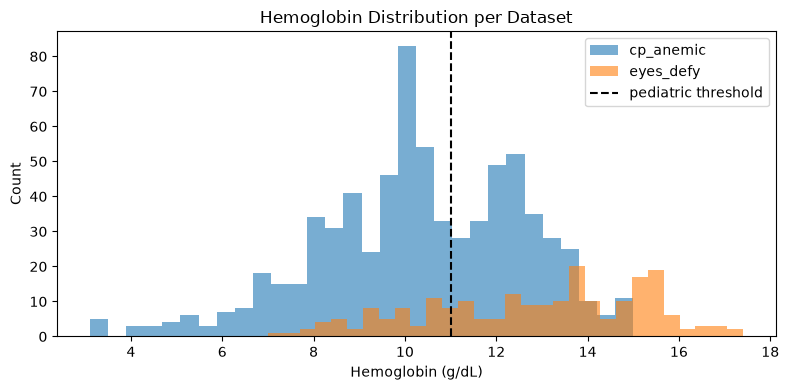

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, group in manifest.groupby("dataset"):
    ax.hist(group["hb_gdl"].dropna(), bins=30, alpha=0.6, label=name)
ax.axvline(11.0, color="black", linestyle="--", label="pediatric threshold")
ax.set_xlabel("Hemoglobin (g/dL)")
ax.set_ylabel("Count")
ax.set_title("Hemoglobin Distribution per Dataset")
ax.legend()
plt.tight_layout()
plt.show()

## Class Balance and Severity

Keseimbangan label anemia per dataset dan distribusi severity yang hanya tersedia pada CP-AnemiC.

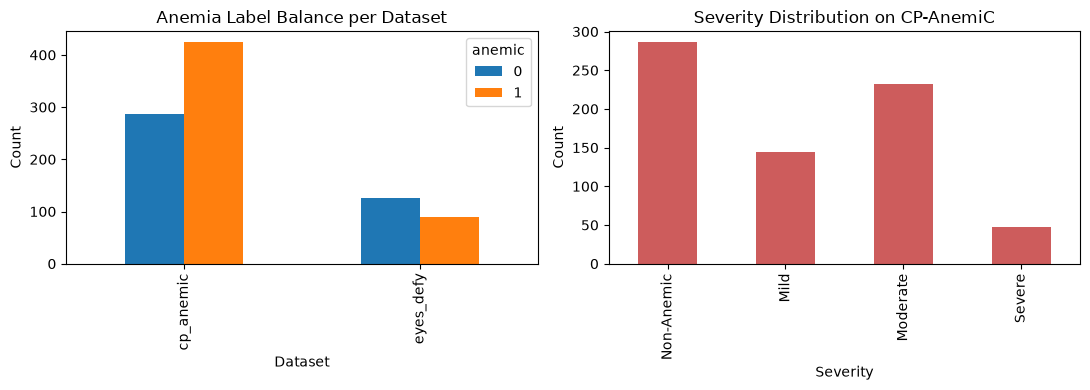

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

anemic_counts = manifest.groupby(["dataset", "anemic"]).size().unstack(fill_value=0)
anemic_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Anemia Label Balance per Dataset")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Count")

severity_order = ["Non-Anemic", "Mild", "Moderate", "Severe"]
cp_frame = manifest[manifest["dataset"] == "cp_anemic"]
severity_counts = cp_frame["severity"].value_counts().reindex(severity_order).fillna(0)
severity_counts.plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Severity Distribution on CP-AnemiC")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Stratified Patient Split

Membagi data menjadi train, validation, dan test secara terstratifikasi per kombinasi dataset dan label anemik agar proporsi kelas terjaga. Setiap baris mewakili satu pasien sehingga pembagian ini setara dengan pembagian berbasis pasien.

In [6]:
manifest = manifest_utils.assign_stratified_split(manifest)
split_counts = manifest.groupby(["dataset", "split"]).size().unstack(fill_value=0)
print(split_counts.to_string())

split      test  train  val
dataset                    
cp_anemic   105    498  107
eyes_defy    31    151   33


## Save Manifest

Manifest final beserta kolom split disimpan ke folder outputs untuk dipakai stage berikutnya.

In [7]:
output_path = paths.outputs_dir("conjunctiva") / "manifest.csv"
manifest.to_csv(output_path, index=False)
print("manifest saved to", output_path)

manifest saved to /home/praktikan/projects/Azril/hemavision/outputs/conjunctiva/manifest.csv
